# Data Exploration: ClidSum XSAMSum Comparison

This notebook compares the `gold_set_50_zh_XSAMSum_bart.json` (model output / gold subset) against the `test.json` (full XSAMSum test split) on the three shared fields:

- `dialogue` — source English dialogue
- `summary` — reference English summary
- `summary_zh` — reference Chinese summary

The goal is to characterize the 50-example gold subset relative to the full test set so we can reason about whether it is representative — important when interpreting any evaluation numbers computed on the subset.

## Setup

In [18]:
import json
import re
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# jieba for Chinese word segmentation (matches ClidSum's evaluation pipeline)
import jieba
jieba.setLogLevel(20)  # suppress init message

pd.set_option('display.max_colwidth', 120)
plt.rcParams['figure.figsize'] = (10, 4)

## Load the data

Adjust `GOLD_PATH` and `TEST_PATH` if the files live elsewhere. Both are expected to be JSON arrays of objects (each with at least `dialogue`, `summary`, `summary_zh`).

In [19]:
GOLD_PATH = Path('gold_set_50_zh_XSAMSum_bart.json')
TEST_PATH = Path('./data/raw/XSAMSum/test.json')

FIELDS = ['dialogue', 'summary', 'summary_zh']

def load_json_records(path):
    """Load a JSON file that is either a list of records or JSONL."""
    text = Path(path).read_text(encoding='utf-8').strip()
    if text.startswith('['):
        return json.loads(text)
    # fall back to JSONL
    return [json.loads(line) for line in text.splitlines() if line.strip()]

gold = load_json_records(GOLD_PATH)
test = load_json_records(TEST_PATH)

print(f'gold records: {len(gold)}')
print(f'test records: {len(test)}')

gold records: 50
test records: 819


### Build DataFrames restricted to the three fields

We keep `id` if it exists for traceability, but everything downstream uses only `dialogue`, `summary`, `summary_zh`.

In [20]:
def to_df(records):
    rows = []
    for r in records:
        row = {f: r.get(f, '') for f in FIELDS}
        if 'id' in r:
            row['id'] = r['id']
        rows.append(row)
    return pd.DataFrame(rows)

gold_df = to_df(gold)
test_df = to_df(test)

gold_df.head(2)

,dialogue,summary,summary_zh
0,"Anne: You were right, he was lying to me :/\nIrene: Oh no, what happened?\nJane: who? that Mark guy?\nAnne: yeah, he...",Mark lied to Anne about his age. Mark is 40.,马克向安妮隐瞒了自己的年龄。他40岁了。
1,"Mary: hey, im kinda broke, lend me a few box\r\nCarter: okay, give me an hour, im at the train station\r\nMary: cool...",Mary ran out of money. Carter is going to lend her some in an hour.,玛丽的钱用完了，卡特打算一小时后借给她一点。


## Length statistics

Three different tokenizations, one per field:
- `dialogue` and `summary` (English): whitespace tokens. Also count utterances in the dialogue (lines).
- `summary_zh` (Chinese): jieba word segmentation, plus character count. We use the same `jieba` pipeline ClidSum uses for `multilingual_rouge_scoring`, so these word counts match what the metric would see.

In [21]:
def en_word_count(s):
    return len(s.split()) if isinstance(s, str) else 0

def zh_word_count(s):
    if not isinstance(s, str) or not s:
        return 0
    return sum(1 for tok in jieba.cut(s) if tok.strip())

def zh_char_count(s):
    if not isinstance(s, str):
        return 0
    return sum(1 for ch in s if '\u4e00' <= ch <= '\u9fff')

def utterance_count(s):
    if not isinstance(s, str) or not s:
        return 0
    # SAMSum-style dialogues use newline-separated 'Speaker: text' lines
    return sum(1 for line in s.splitlines() if line.strip())

def add_length_columns(df):
    df = df.copy()
    df['dialogue_words']    = df['dialogue'].map(en_word_count)
    df['dialogue_utts']     = df['dialogue'].map(utterance_count)
    df['summary_words']     = df['summary'].map(en_word_count)
    df['summary_zh_words']  = df['summary_zh'].map(zh_word_count)
    df['summary_zh_chars']  = df['summary_zh'].map(zh_char_count)
    return df

gold_df = add_length_columns(gold_df)
test_df = add_length_columns(test_df)

length_cols = ['dialogue_words', 'dialogue_utts', 'summary_words', 'summary_zh_words', 'summary_zh_chars']

summary_stats = pd.concat({
    'gold (n=%d)' % len(gold_df): gold_df[length_cols].describe().round(2),
    'test (n=%d)' % len(test_df): test_df[length_cols].describe().round(2),
}, axis=1)
summary_stats

gold (n=50)                                               \
      dialogue_words dialogue_utts summary_words summary_zh_words   
count          50.00         50.00         50.00            50.00   
mean           76.58         10.12         17.34            18.80   
std            62.30          5.71          7.68             8.38   
min             9.00          3.00          4.00             5.00   
25%            41.75          6.00         12.00            12.25   
50%            68.50          8.50         16.00            19.00   
75%            90.75         12.00         20.75            22.00   
max           424.00         28.00         40.00            44.00   

                         test (n=819)                              \
      summary_zh_chars dialogue_words dialogue_utts summary_words   
count            50.00         819.00        819.00        819.00   
mean             26.14          95.51         11.25         20.02   
std              11.58          75.23          6.35         10.65   
min               7.00           9.00          3.00          3.00   
25%              17.00          42.00          6.00         12.00   
50%              25.00          74.00         10.00         18.00   
75%              30.00         126.00         15.00         26.00   
max              64.00         516.00         30.00         58.00   

                                         
      summary_zh_words summary_zh_chars  
count           819.00           819.00  
mean             21.39            31.01  
std              11.53            16.61  
min               4.00             5.00  
25%              12.00            18.00  
50%              19.00            28.00  
75%              28.00            40.00  
max              71.00           109.00

### Visual comparison of length distributions

Histograms with the test set as the reference distribution and the gold set overlaid. If the gold set is a representative sample, its distribution should sit inside the test set's envelope.

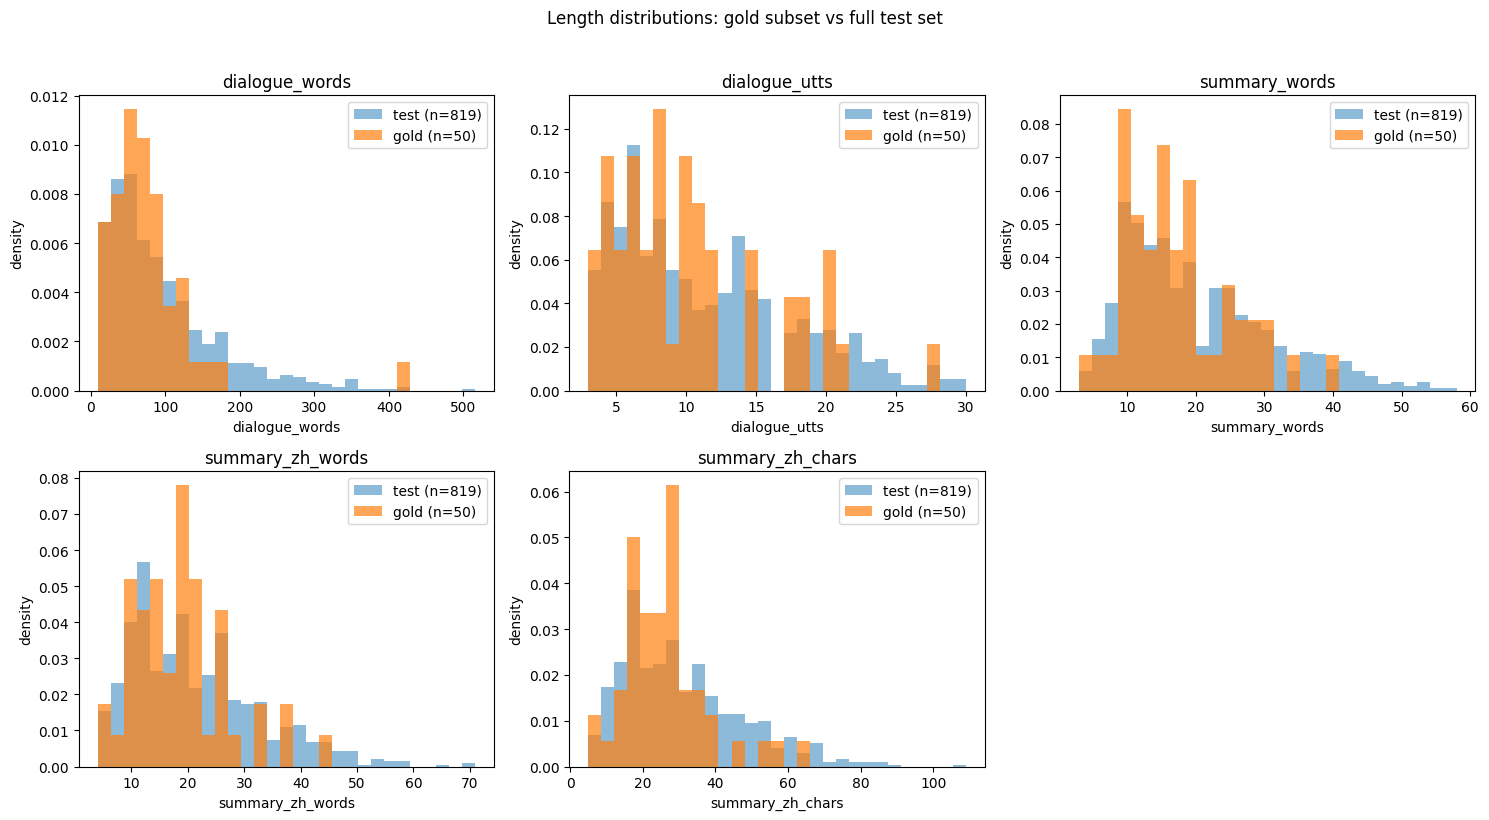

In [22]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, col in zip(axes, length_cols):
    lo = min(test_df[col].min(), gold_df[col].min())
    hi = max(test_df[col].max(), gold_df[col].max())
    bins = np.linspace(lo, hi, 30)
    ax.hist(test_df[col], bins=bins, alpha=0.5, label=f'test (n={len(test_df)})', density=True)
    ax.hist(gold_df[col], bins=bins, alpha=0.7, label=f'gold (n={len(gold_df)})', density=True)
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel('density')
    ax.legend()

axes[-1].axis('off')
fig.suptitle('Length distributions: gold subset vs full test set', y=1.02)
fig.tight_layout()
plt.show()

### Cross-language length ratio

How much does the Chinese summary expand or contract relative to the English summary? Two views:
- `summary_zh_chars / summary_words` — characters per English word (typical SAMSum→XSAMSum ratio is ~1.0–1.5)
- `summary_zh_words / summary_words` — jieba words per English word (closer to 1.0)

In [23]:
def add_ratio_columns(df):
    df = df.copy()
    sw = df['summary_words'].replace(0, np.nan)
    df['zh_chars_per_en_word'] = df['summary_zh_chars'] / sw
    df['zh_words_per_en_word'] = df['summary_zh_words'] / sw
    return df

gold_df = add_ratio_columns(gold_df)
test_df = add_ratio_columns(test_df)

ratio_cols = ['zh_chars_per_en_word', 'zh_words_per_en_word']
pd.concat({
    'gold': gold_df[ratio_cols].describe().round(3),
    'test': test_df[ratio_cols].describe().round(3),
}, axis=1)

gold                                      test  \
      zh_chars_per_en_word zh_words_per_en_word zh_chars_per_en_word   
count               50.000               50.000              819.000   
mean                 1.538                1.099                1.571   
std                  0.283                0.191                0.283   
min                  0.900                0.700                0.722   
25%                  1.333                0.969                1.400   
50%                  1.544                1.095                1.556   
75%                  1.741                1.214                1.730   
max                  2.500                1.600                3.000   

                            
      zh_words_per_en_word  
count              819.000  
mean                 1.081  
std                  0.196  
min                  0.500  
25%                  0.960  
50%                  1.069  
75%                  1.188  
max                  2.000

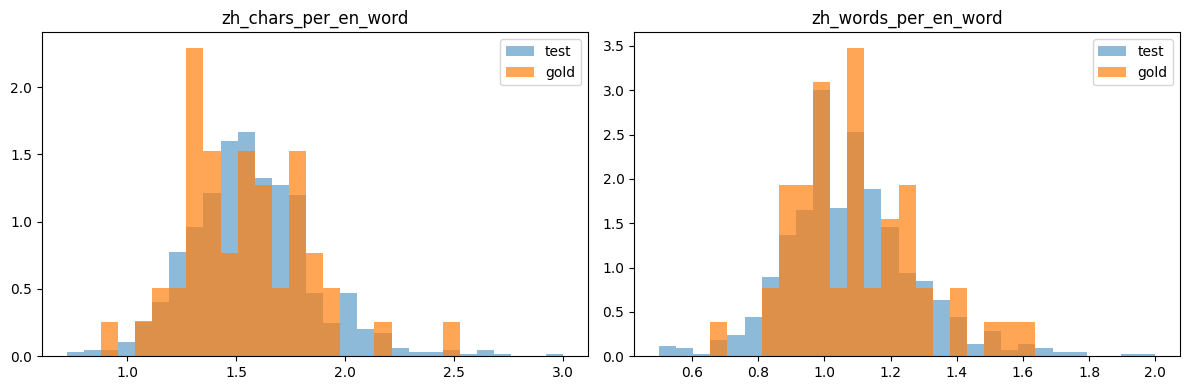

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col in zip(axes, ratio_cols):
    lo = min(test_df[col].min(), gold_df[col].min())
    hi = max(test_df[col].max(), gold_df[col].max())
    bins = np.linspace(lo, hi, 30)
    ax.hist(test_df[col].dropna(), bins=bins, alpha=0.5, label='test', density=True)
    ax.hist(gold_df[col].dropna(), bins=bins, alpha=0.7, label='gold', density=True)
    ax.set_title(col)
    ax.legend()
fig.tight_layout()
plt.show()

## Speaker / dialogue structure

SAMSum-style dialogues encode the speaker as `Name:` at the start of each line. Two questions:
- How many distinct speakers per dialogue?
- Is the gold subset's distribution of speaker-counts comparable to the test set's?

        gold    test
count  50.00  819.00
mean    2.44    2.36
std     1.09    0.83
min     2.00    2.00
25%     2.00    2.00
50%     2.00    2.00
75%     3.00    2.00
max     9.00   11.00


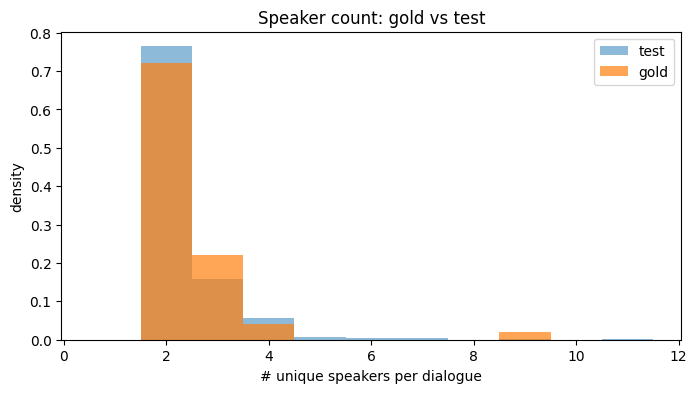

In [25]:
SPEAKER_RE = re.compile(r'^([^:\n]{1,30}):', re.MULTILINE)

def speakers_in(dialogue):
    if not isinstance(dialogue, str):
        return []
    return [m.group(1).strip() for m in SPEAKER_RE.finditer(dialogue)]

def num_unique_speakers(dialogue):
    return len(set(speakers_in(dialogue)))

gold_df['n_speakers'] = gold_df['dialogue'].map(num_unique_speakers)
test_df['n_speakers'] = test_df['dialogue'].map(num_unique_speakers)

spk_stats = pd.concat({
    'gold': gold_df['n_speakers'].describe().round(2),
    'test': test_df['n_speakers'].describe().round(2),
}, axis=1)
print(spk_stats)

fig, ax = plt.subplots(figsize=(8, 4))
max_spk = int(max(test_df['n_speakers'].max(), gold_df['n_speakers'].max()))
bins = np.arange(0.5, max_spk + 1.5, 1)
ax.hist(test_df['n_speakers'], bins=bins, alpha=0.5, label='test', density=True)
ax.hist(gold_df['n_speakers'], bins=bins, alpha=0.7, label='gold', density=True)
ax.set_xlabel('# unique speakers per dialogue')
ax.set_ylabel('density')
ax.set_title('Speaker count: gold vs test')
ax.legend()
plt.show()

## Compression ratios

How aggressively does each summary compress its dialogue? Useful to verify the gold set isn't drawn predominantly from the easy (high-compression) or hard (low-compression) tail.

In [26]:
def add_compression_columns(df):
    df = df.copy()
    dw = df['dialogue_words'].replace(0, np.nan)
    df['compression_en'] = df['summary_words'] / dw
    df['compression_zh'] = df['summary_zh_words'] / dw
    return df

gold_df = add_compression_columns(gold_df)
test_df = add_compression_columns(test_df)

comp_cols = ['compression_en', 'compression_zh']
pd.concat({
    'gold': gold_df[comp_cols].describe().round(3),
    'test': test_df[comp_cols].describe().round(3),
}, axis=1)

gold                          test               
      compression_en compression_zh compression_en compression_zh
count         50.000         50.000        819.000        819.000
mean           0.293          0.323          0.290          0.310
std            0.146          0.180          0.173          0.189
min            0.061          0.074          0.033          0.030
25%            0.184          0.193          0.163          0.167
50%            0.263          0.291          0.250          0.265
75%            0.399          0.432          0.385          0.405
max            0.708          0.792          1.222          1.333

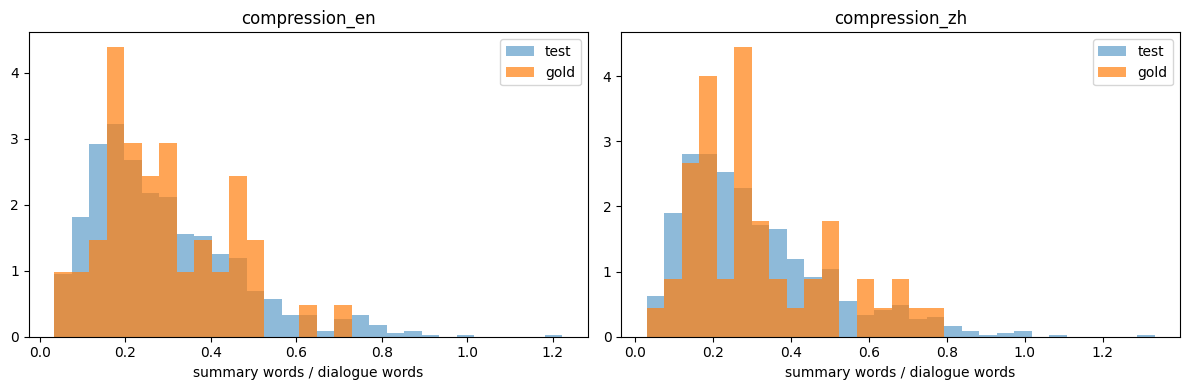

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col in zip(axes, comp_cols):
    lo = min(test_df[col].min(), gold_df[col].min())
    hi = max(test_df[col].max(), gold_df[col].max())
    bins = np.linspace(lo, hi, 30)
    ax.hist(test_df[col].dropna(), bins=bins, alpha=0.5, label='test', density=True)
    ax.hist(gold_df[col].dropna(), bins=bins, alpha=0.7, label='gold', density=True)
    ax.set_title(col)
    ax.set_xlabel('summary words / dialogue words')
    ax.legend()
fig.tight_layout()
plt.show()

## Representativeness check (KS test)

A one-shot two-sample Kolmogorov–Smirnov test on each length feature. A small p-value means the gold subset's distribution differs significantly from the test set on that feature — which is fine for a model-output sample but worth flagging if the gold set was meant to be representative.

Caveat: with n=50 vs n≈800, the test has limited power, so a large p-value is weak evidence of equivalence, not proof.

In [28]:
!pip install scipy

from scipy.stats import ks_2samp

rows = []
for col in length_cols + ['n_speakers'] + comp_cols:
    g = gold_df[col].dropna()
    t = test_df[col].dropna()
    stat, p = ks_2samp(g, t)
    rows.append({'feature': col, 'gold_mean': g.mean(), 'test_mean': t.mean(),
                 'KS_stat': stat, 'p_value': p})

ks_df = pd.DataFrame(rows).round(4)
ks_df['differs_at_0.05'] = ks_df['p_value'] < 0.05
ks_df

,feature,gold_mean,test_mean,KS_stat,p_value,differs_at_0.05
0,dialogue_words,76.5800,95.5079,0.1776,0.0896,False
1,dialogue_utts,10.1200,11.2479,0.1532,0.1966,False
2,summary_words,17.3400,20.0171,0.1454,0.2462,False
3,summary_zh_words,18.8000,21.3871,0.1666,0.1297,False
4,summary_zh_chars,26.1400,31.0110,0.2168,0.0200,True
5,n_speakers,2.4400,2.3590,0.0443,0.9999,False
6,compression_en,0.2925,0.2900,0.1034,0.6541,False
7,compression_zh,0.3232,0.3099,0.0979,0.7179,False
